# BANK MARKETING

#### IMPORTING LIBRARIES

In [92]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### IMPORTING CSV FILE

In [93]:
df = pd.read_csv(r"C:\Users\simra\OneDrive\Desktop\Internship Projects\Bank Marketing Data Analysis\bank statement excel(Original).csv")

#### EXPLORATORY DATA ANALYSIS

In [94]:
df.head()

,age,job,marital,education,defaulters,housing loan,personal loan,contact,month,day_of_week,...,campaign(no of calls),pdays(last contacted),previous(contcated before compaign),poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y (subscribed)
0,17,student,single,unknown,no,yes,no,cellular,aug,wed,...,3,4,2,success,-2.9,92.201,-31.4,0.884,5076.2,no
1,17,student,single,basic.9y,no,yes,no,cellular,aug,fri,...,2,999,2,failure,-2.9,92.201,-31.4,0.869,5076.2,no
2,17,student,single,basic.9y,no,yes,no,cellular,aug,fri,...,3,4,2,success,-2.9,92.201,-31.4,0.869,5076.2,no
3,17,student,single,basic.9y,no,unknown,unknown,cellular,aug,fri,...,2,999,1,failure,-2.9,92.201,-31.4,0.869,5076.2,yes
4,17,student,single,unknown,no,no,yes,cellular,oct,tue,...,1,2,2,success,-3.4,92.431,-26.9,0.742,5017.5,yes


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  41188 non-null  int64  
 1   job                                  41188 non-null  object 
 2   marital                              41188 non-null  object 
 3   education                            41188 non-null  object 
 4   defaulters                           41188 non-null  object 
 5   housing loan                         41188 non-null  object 
 6   personal loan                        41188 non-null  object 
 7   contact                              41188 non-null  object 
 8   month                                41188 non-null  object 
 9   day_of_week                          41188 non-null  object 
 10  duration                             41188 non-null  int64  
 11  campaign(no of calls)       

## DATA CLEANING

In [96]:
# CHECKING NULL VALUES
df.isnull().sum()

age                                    0
job                                    0
marital                                0
education                              0
defaulters                             0
housing loan                           0
personal loan                          0
contact                                0
month                                  0
day_of_week                            0
duration                               0
campaign(no of calls)                  0
pdays(last contacted)                  0
previous(contcated before compaign)    0
poutcome                               0
emp.var.rate                           0
cons.price.idx                         0
cons.conf.idx                          0
euribor3m                              0
nr.employed                            0
y (subscribed)                         0
dtype: int64

In [97]:
# CHECKING DUPLICATE ROWS
df.duplicated().sum()

# so there are 12 duplicate rows in this dataset.

np.int64(12)

In [98]:
# REMOVING DUPLICATE ROWS
df.drop_duplicates(inplace= True)

In [99]:
df.shape

(41176, 21)

In [100]:
df.columns

Index(['age', 'job', 'marital', 'education', 'defaulters', 'housing loan',
       'personal loan', 'contact', 'month', 'day_of_week', 'duration',
       'campaign(no of calls)', 'pdays(last contacted)',
       'previous(contcated before compaign)', 'poutcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'y (subscribed)'],
      dtype='object')

In [101]:
df.columns = df.columns.str.replace(" ", "_")

In [102]:
# Standardize column names for better readability
df.rename(columns ={
    "campaign(no_of_calls)":"campaign",
    "pdays(last_contacted)":"pdays",
    'previous(contcated_before_compaign)':'previous',
    'y_(subscribed)': 'y'
    }, inplace = True)

In [103]:
df.columns

Index(['age', 'job', 'marital', 'education', 'defaulters', 'housing_loan',
       'personal_loan', 'contact', 'month', 'day_of_week', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

##### HANDLING UNKNOWN VALUES

In [104]:
# Percentage of each job category in the dataset
(df["job"].value_counts(normalize=True)*100).round(2)

job
admin.           25.30
blue-collar      22.47
technician       16.37
services          9.63
management        7.10
retired           4.17
entrepreneur      3.54
self-employed     3.45
housemaid         2.57
unemployed        2.46
student           2.13
unknown           0.80
Name: proportion, dtype: float64

In [105]:
# REPLACING UNKNOWN IN JOB COLUMN WITH MOODE
mode_value = df["job"].mode()[0]
df["job"] = df["job"].replace('unknown', mode_value)


In [106]:
# Percentage of each marital category in the dataset
df["marital"].value_counts(normalize = True).round(2)

marital
married     0.61
single      0.28
divorced    0.11
unknown     0.00
Name: proportion, dtype: float64

In [107]:
# REPLACING UNKNOWN IN MARITAL COLUMN WITH MODE
mode_value = df["marital"].mode()[0]
df["marital"] = df["marital"].replace("unknown", mode_value)

In [108]:
# Percentage of each education category in the dataset
df["education"].value_counts(normalize = True).round(2)

education
university.degree      0.30
high.school            0.23
basic.9y               0.15
professional.course    0.13
basic.4y               0.10
basic.6y               0.06
unknown                0.04
illiterate             0.00
Name: proportion, dtype: float64

In [109]:
# # REPLACING UNKNOWN IN EDUCATION COLUMN WITH MODE
mode_value = df["education"].mode()[0]
df["education"] = df["education"].replace("unknown", mode_value)

In [111]:
# Percentage of each housing loan category in the dataset
df["housing_loan"].value_counts(normalize = True).round(2)

housing_loan
yes        0.52
no         0.45
unknown    0.02
Name: proportion, dtype: float64

In [112]:
# REPLACING UNKNOWN IN HOUSING LOAN COLUMN WITH MODE
mode_value = df["housing_loan"].mode()[0]
df["housing_loan"] = df["housing_loan"].replace("unknown", mode_value)


In [113]:
# Percentage of each personal loan category in the dataset
df["personal_loan"].value_counts(normalize = True).round(2)

personal_loan
no         0.82
yes        0.15
unknown    0.02
Name: proportion, dtype: float64

In [114]:
# REPLACING UNKNOWN IN PERSONAL LOAN COLUMN WITH MODE
mode_value = df["personal_loan"].mode()[0]
df["personal_loan"] = df["personal_loan"].replace("unknown", mode_value)

In [115]:
# Percentage of each contact category in the dataset
df["contact"].value_counts(normalize = True).round(2)

contact
cellular     0.63
telephone    0.37
Name: proportion, dtype: float64

In [72]:
# Percentage of each month category in the dataset
df["month"].value_counts(normalize = True).round(2)

month
may    0.33
jul    0.17
aug    0.15
jun    0.13
nov    0.10
apr    0.06
oct    0.02
sep    0.01
mar    0.01
dec    0.00
Name: proportion, dtype: float64

In [116]:
# Percentage of each day of the week category in the dataset
df["day_of_week"].value_counts(normalize = True).round(2)

day_of_week
thu    0.21
mon    0.21
wed    0.20
tue    0.20
fri    0.19
Name: proportion, dtype: float64

In [117]:
# Percentage of each poutcome category in the dataset
df["poutcome"].value_counts(normalize = True).round(2)

# we will not change non existent to mode as this contains 86% of the data we will treat it as a column.

poutcome
nonexistent    0.86
failure        0.10
success        0.03
Name: proportion, dtype: float64

In [118]:
# Percentage of each subscribed category in the dataset
df["y"].value_counts(normalize = True).round(2)

y
no     0.89
yes    0.11
Name: proportion, dtype: float64

##### CHECKING THE OUTLIERS

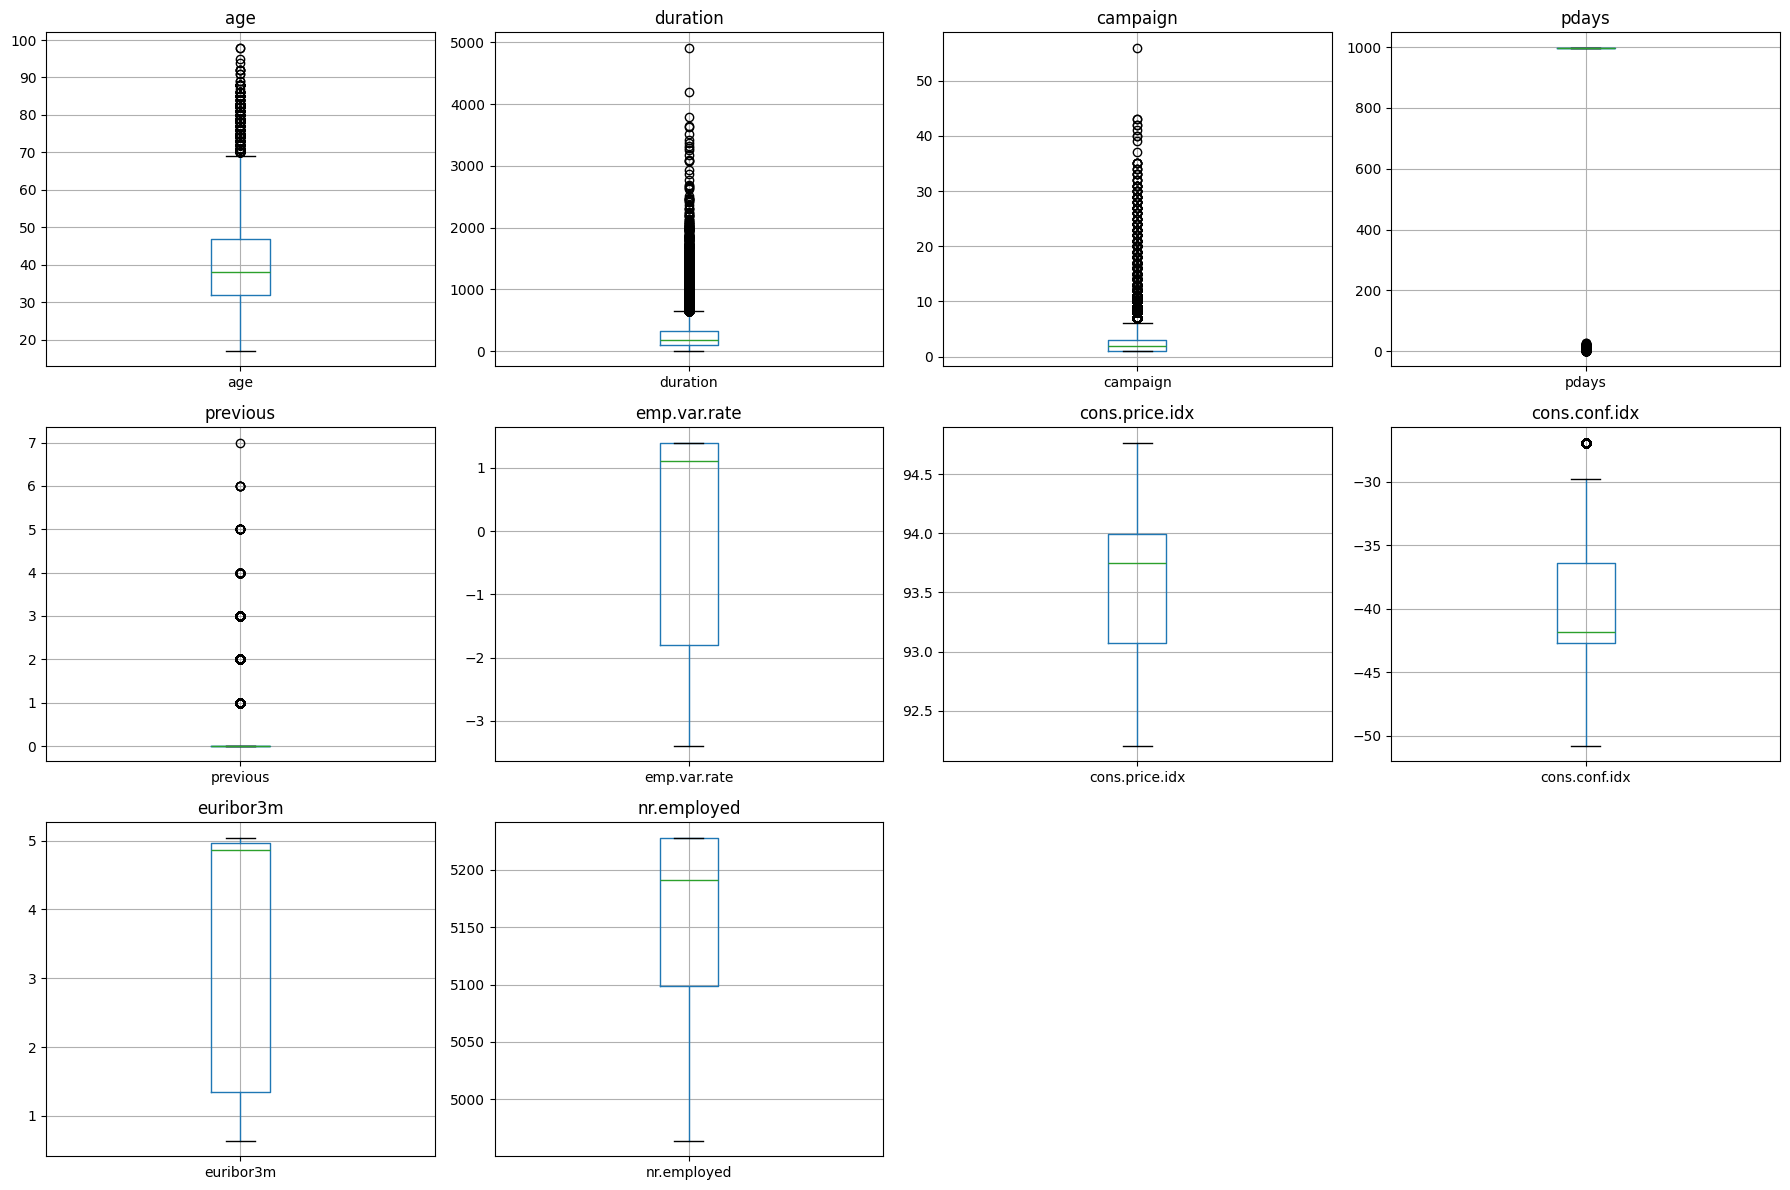

In [119]:
import matplotlib.pyplot as plt

# numeric columns from your dataset
num_cols = [
    'age',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 4, i)
    df.boxplot(column=col)
    plt.title(col)

plt.tight_layout()
plt.show()

##### OUTLIERS
age : max value is 98, so it is possible that a 98 years old person is contacted so this is not an outlier

duration : max value is 4918 seconds that means one and a half hour almost so this can also be possible 

campaign : max value is 56 which means number of times the bank called the customer 56 calls can be possible if the customer is showing interest

pdays : max value is 999 whaich means person contacted last 999 days ago almost 3 years ago that is an outlier because this can be possible but this is not a useful information as there are no chances that person will subscribe

previous : max vcalue is 7 so it possible that person is contacted 7 times before the campaign 


In [120]:
# REPLACING 999 WITH NAN IN PDAYS COLUMN
df['pdays'] = df['pdays'].replace(999, 'never_contacted')

In [121]:
df['pdays'].dtype

dtype('O')

## EXPLORATORY DATA ANALYSIS

In [122]:
df.describe()

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [123]:
# MAPPING THE SUBSCRIPTION COLUMN TO BINARY VALUES
df['y_new'] = df['y'].map({'yes': 1, 'no': 0})

In [124]:
# CORRELATION BETWEEN NUMERIC COLUMNS
df.corr(numeric_only=True)

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_new
age,1.000000,-0.000808,0.004622,0.024379,-0.000242,0.001009,0.129075,0.010852,-0.017607,0.030381
duration,-0.000808,1.000000,-0.071765,0.020600,-0.027941,0.005303,-0.008126,-0.032861,-0.044672,0.405297
campaign,0.004622,-0.071765,1.000000,-0.079182,0.150786,0.127826,-0.013657,0.135169,0.144129,-0.066361
previous,0.024379,0.020600,-0.079182,1.000000,-0.420587,-0.203197,-0.050929,-0.454571,-0.501411,0.230202
emp.var.rate,-0.000242,-0.027941,0.150786,-0.420587,1.000000,0.775293,0.196257,0.972244,0.906949,-0.298289
cons.price.idx,0.001009,0.005303,0.127826,-0.203197,0.775293,1.000000,0.059170,0.688180,0.521945,-0.136134
cons.conf.idx,0.129075,-0.008126,-0.013657,-0.050929,0.196257,0.059170,1.000000,0.277864,0.100679,0.054802
euribor3m,0.010852,-0.032861,0.135169,-0.454571,0.972244,0.688180,0.277864,1.000000,0.945146,-0.307740
nr.employed,-0.017607,-0.044672,0.144129,-0.501411,0.906949,0.521945,0.100679,0.945146,1.000000,-0.354669
y_new,0.030381,0.405297,-0.066361,0.230202,-0.298289,-0.136134,0.054802,-0.307740,-0.354669,1.000000


#### there is a strong relation btwn duration and subscription(correlation is 0.40) means the longer the call the chances of subscription will be more
there is a strong relation btwn previous and subscription(correlation is 0.23) means if there are more number of contacts before campaign the chances of subscription is more.

nr.employed = -0.35 when More employment → lower subscription rate, When economy is strong, people are less likely to invest in deposits
euribor3m = -0.30 Higher interest rates → lower subscription


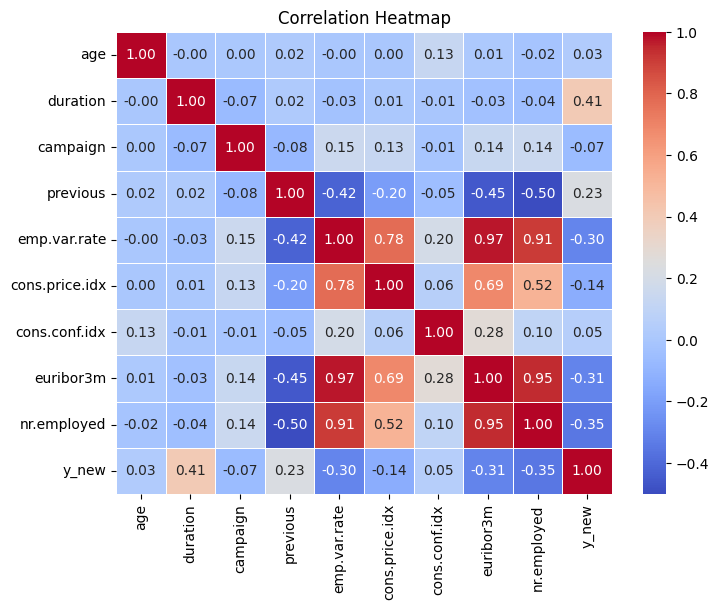

In [ ]:
# HEATMAP FOR CORRELATION BETWEEN NUMERIC COLUMNS
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [91]:
df.to_csv(r"C:\Users\simra\OneDrive\Desktop\Internship Projects\Bank Marketing Data Analysis(clean).csv", index=False)

In [129]:
# CONVERTING AGE COLUMN INTO CATEGORICAL COLUMN
df["age_group"] = pd.cut(
    df["age"],
    bins = [0,19,39,59,100],
    labels = ["Teenager", "Adult", "Middle-aged", "Old"]
)

In [90]:
# CHANGING THE DATATYPE OF AGE_GROUP COLUMN TO STRING
df["age_group"] = df["age_group"].astype(str)

In [ ]:
# CREATING DURATION GROUPS
df['duration_group'] = pd.cut(
    df['duration'],
    bins=[0, 100, 200, 300, 500, 1000, df['duration'].max()],
    labels=[
        '0-100 sec',
        '101-200 sec',
        '201-300 sec',
        '301-500 sec',
        '501-1000 sec',
        '1000+ sec'
    ],
    include_lowest=True
)

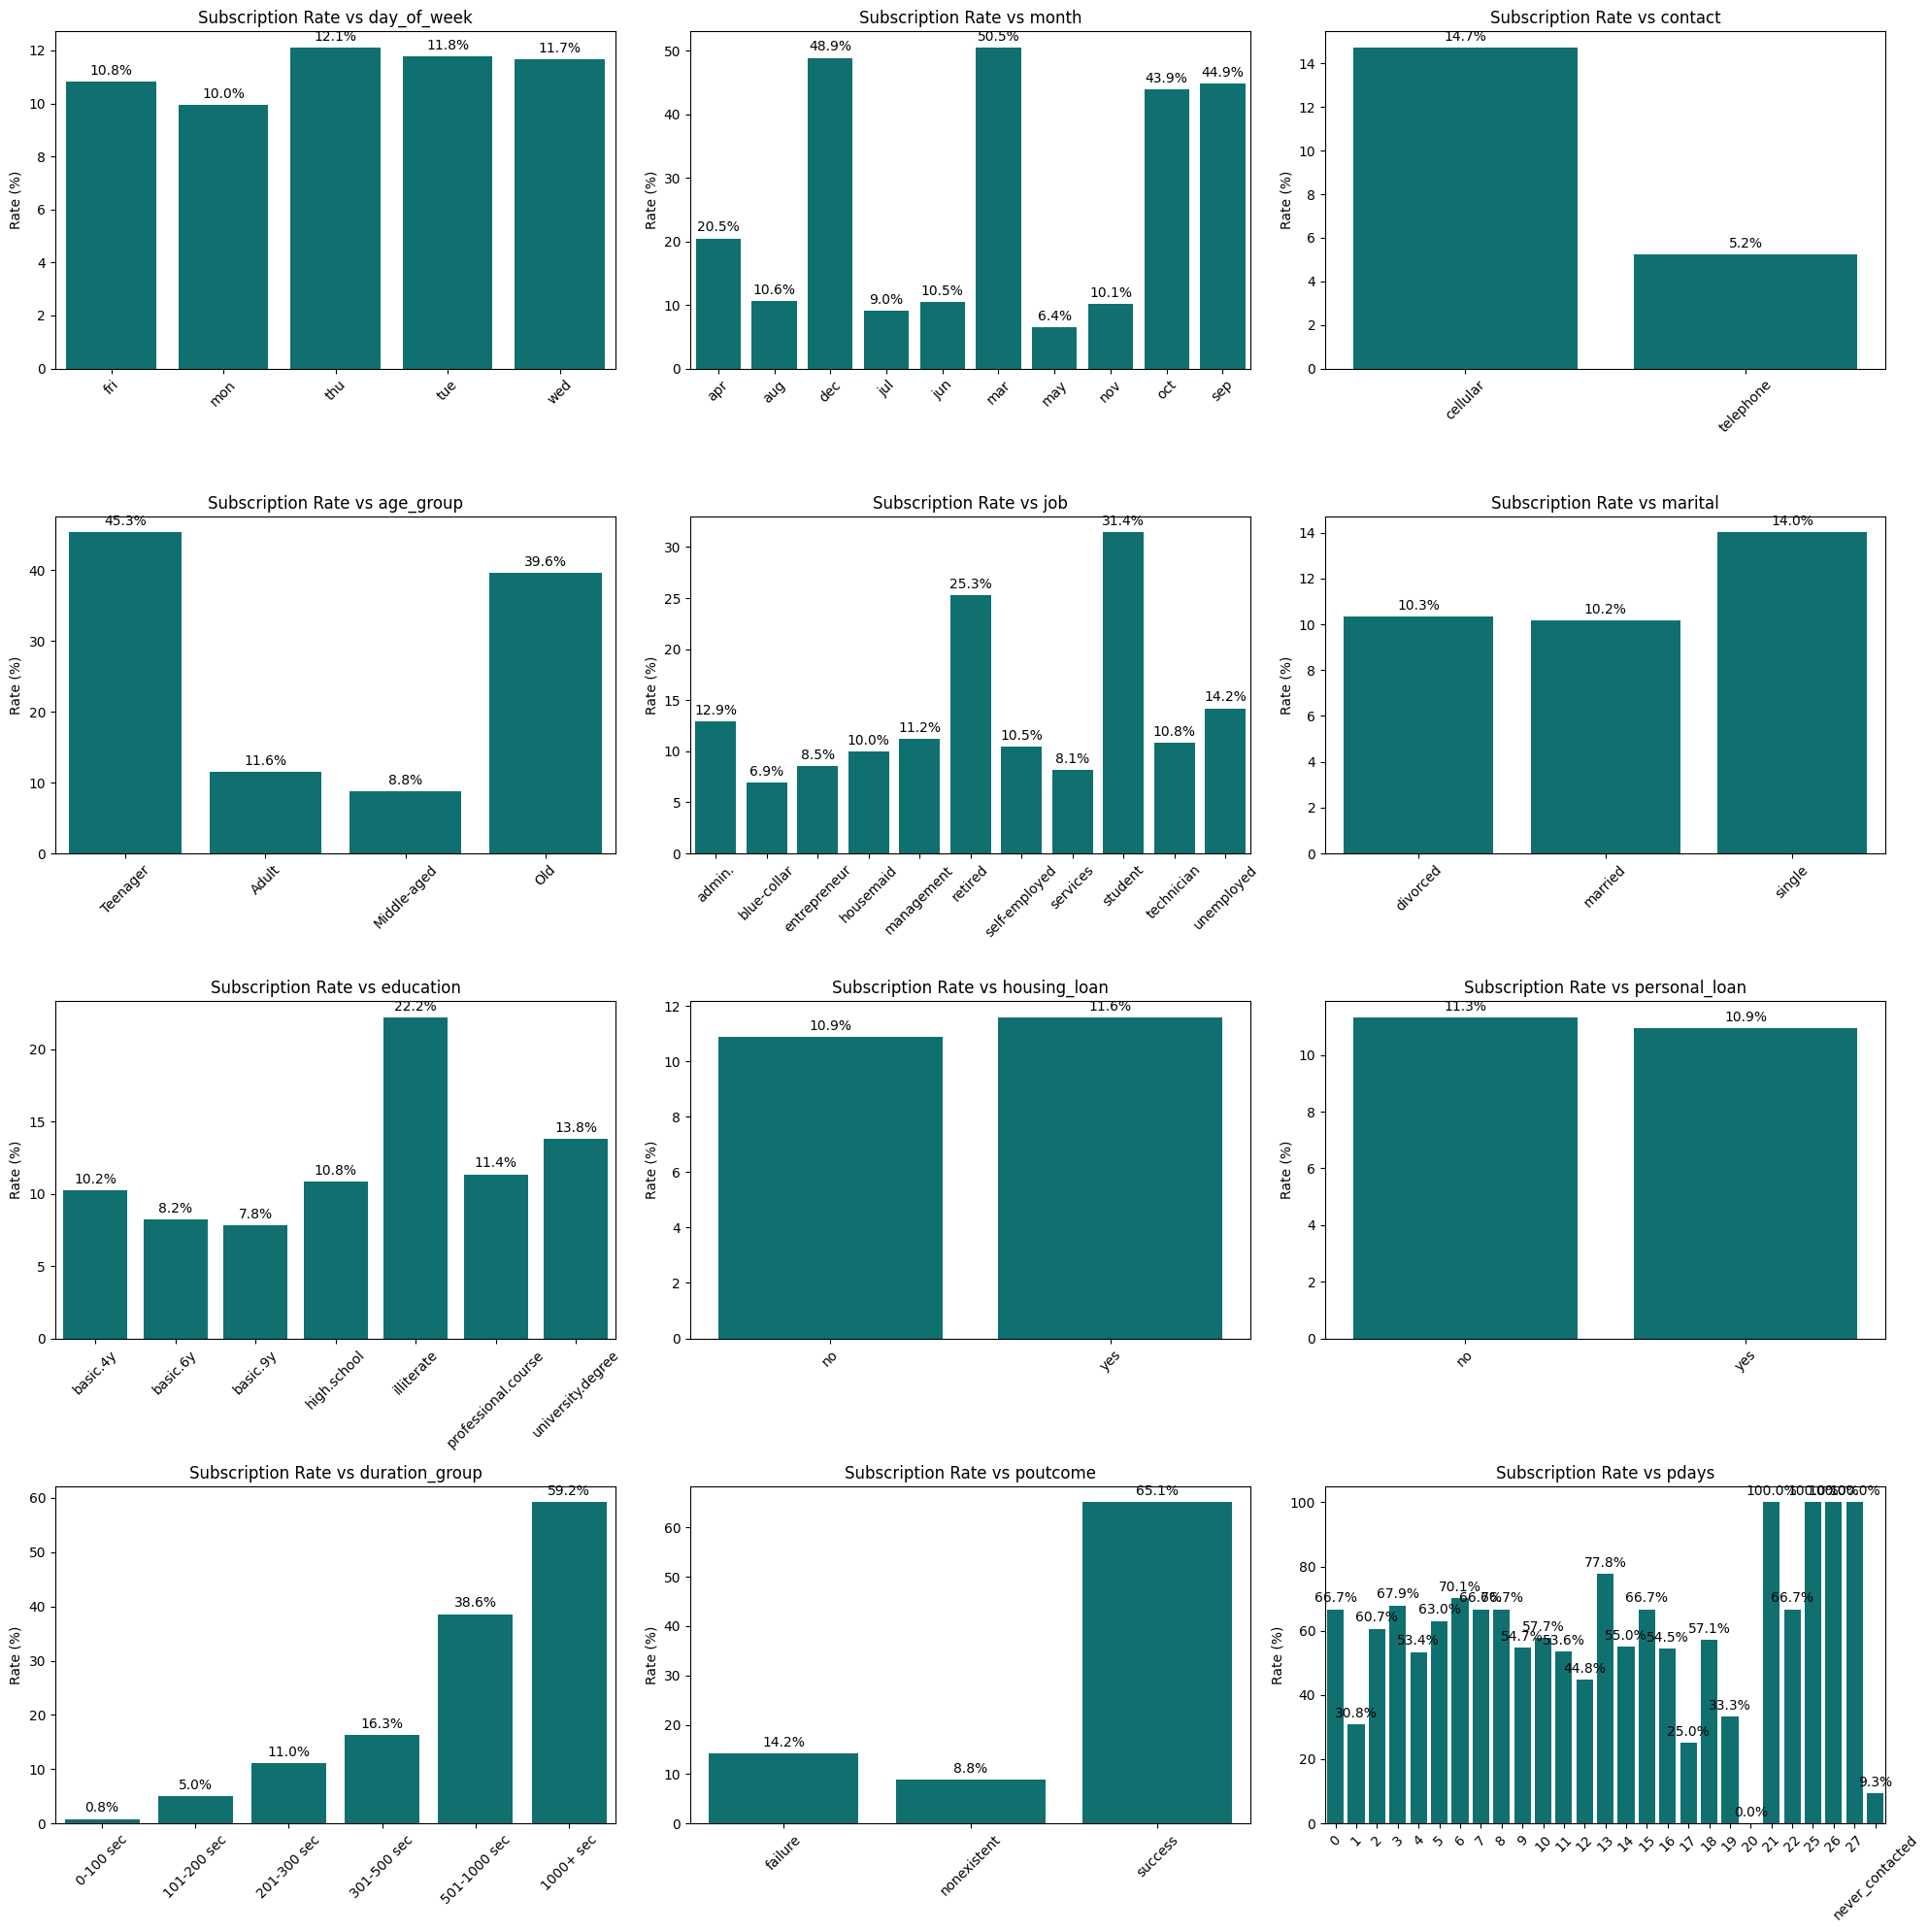

In [ ]:
# VISUALIZING THE SUBSCRIPTION RATE AGAINST CATEGORICAL AND CONTINUOUS VARIABLES
cols = [
    'day_of_week', 'month', 'contact', 'age_group',
    'job', 'marital', 'education', 'housing_loan',
    'personal_loan', 'duration_group','poutcome', 'pdays'
]

fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols):

    summary = (
        df.groupby(col, observed=False)['y_new']
          .mean()
          .reset_index()
    )

    summary['subscription_rate'] = summary['y_new'] * 100

    sns.barplot(
        data=summary,
        x=col,
        y='subscription_rate',
        ax=axes[i],
        color= 'teal'
    )

    axes[i].set_title(f'Subscription Rate vs {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# CREATING BINS FOR ECONOMIC VARIABLES
df['emp.var.rate_group'] = np.where(
    df['emp.var.rate'] <= 0,
    'Economic Downturn',
    'Stable or Growth'
)

df['cons.price.idx_group'] = np.where(
    df['cons.price.idx'] <= 93.0,
    'Low CPI',
    'High CPI'
)

df['cons.conf.idx_group'] = np.where(
    df['cons.conf.idx'] <= -40,
    'Low Confidence',
    'High Confidence'
)

df['euribor3m_group'] = np.where(
    df['euribor3m'] <= 1.0,
    'Low',
    np.where(
        df['euribor3m'] <= 3,
        'Medium',
        'High'
    )
)


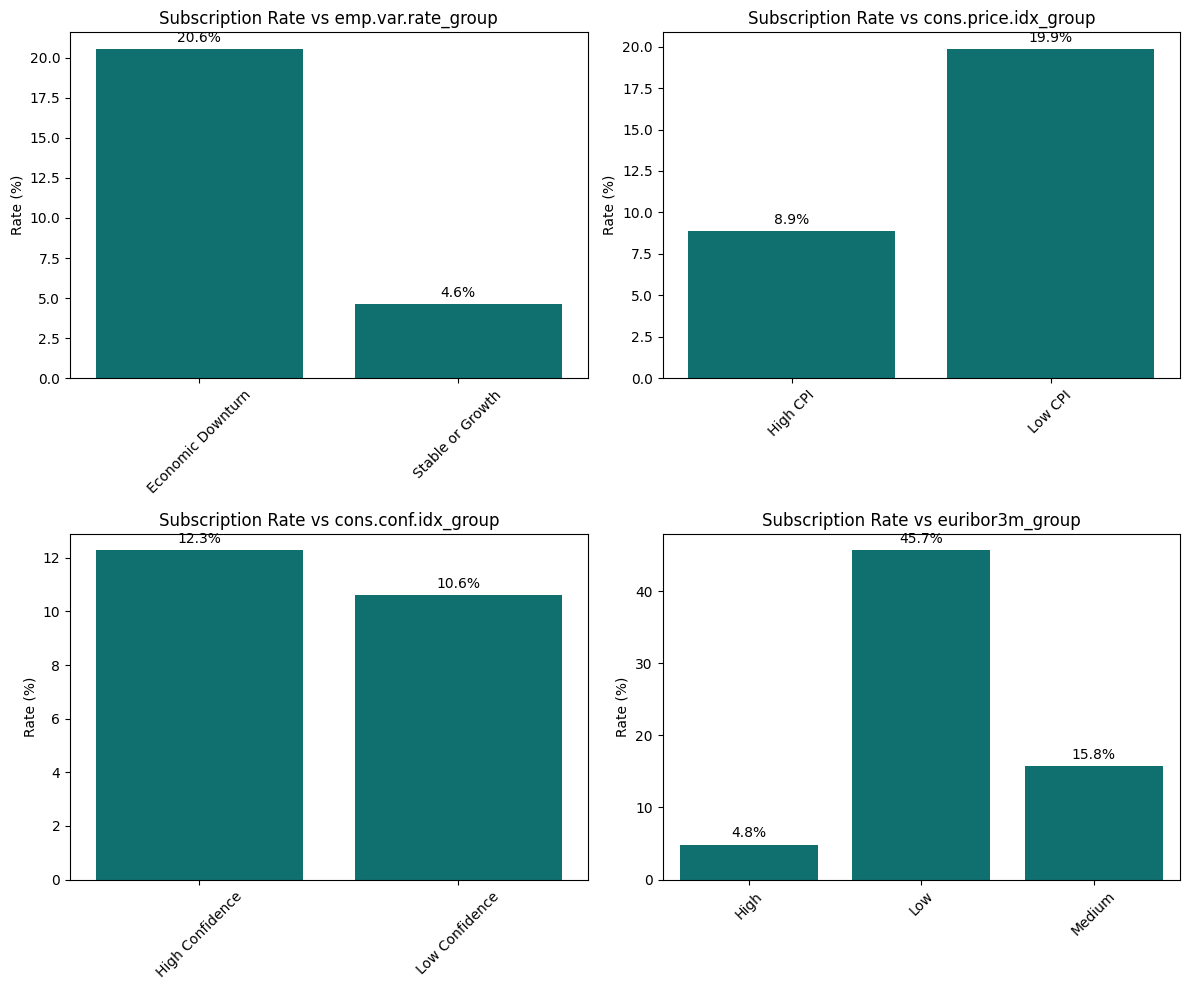

In [ ]:
# VISUALIZING THE SUBSCRIPTION RATE AGAINST ECONOMIC VARIABLES
cols = [
    'emp.var.rate_group','cons.price.idx_group', 'cons.conf.idx_group', 'euribor3m_group'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cols):

    summary = (
        df.groupby(col, observed=False)['y_new']
          .mean()
          .reset_index()
    )

    summary['subscription_rate'] = summary['y_new'] * 100

    sns.barplot(
        data=summary,
        x=col,
        y='subscription_rate',
        ax=axes[i],
        color= 'teal'
    )

    axes[i].set_title(f'Subscription Rate vs {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

## Conclusion

This analysis explored the factors influencing customer subscription to term deposits in a bank marketing campaign. Through data cleaning, exploratory data analysis, and visualization, several important patterns were identified.

Key findings indicate that previous campaign outcomes, contact methods, call duration, and economic indicators such as Euribor rates and employment variation rates have a significant impact on customer subscription behavior. Customers who had positive outcomes in previous campaigns showed a higher likelihood of subscribing. Similarly, longer call durations were associated with higher conversion rates.

Demographic factors such as age, job type, education level, and marital status also influenced subscription rates, although their impact varied across customer groups. Economic conditions played an important role, with subscription behavior changing under different interest rate and employment environments.

Based on these insights, the bank can improve campaign effectiveness by targeting customer segments with higher conversion potential, optimizing contact strategies, and considering economic conditions when planning marketing activities. These findings can help increase subscription rates while reducing unnecessary marketing costs.

The bank should focus on more longer call duration, lesser campaign and interacting with customers in the middle of the week 
Focus more on Married people, Adults, who have University Degree.
